# ПЭТ-проект: forklift_price_analysis
> **Цель:** Подготовка данных, извлечение характеристик и построение гедонической ценовой модели вилочных погрузчиков.

## ЭТАП 1. Первичная очистка и подготовка данных (Data Cleaning)

Раздел включает базовую чистку технических колонок, обработку явных пропусков и удаление точных дубликатов.

Импорты, загрузка датасета и первичный просмотр

In [49]:
# --- Базовые библиотеки для работы с данными ---
import pandas as pd                  # Библиотека Pandas: загрузка, очистка и обработка табличных данных
import numpy as np                   # Библиотека NumPy: математические операции и работа с массивами
import scipy.stats as stats          # Модуль stats из SciPy: статистические тесты (в т.ч. проверка на нормальность)

# --- Библиотеки для визуализации данных ---
import matplotlib.pyplot as plt      # Модуль pyplot из Matplotlib: создание базовых графиков и гистограмм
import seaborn as sns                # Библиотека Seaborn: продвинутые статистические графики (тепловые карты и др.)
import plotly.express as px          # Модуль express из Plotly: создание интерактивных графиков
import missingno as msno # Матрица missingno — это визуализация нашего DataFrame, где белые полосы — это пропуски.
# Она помогает мгновенно увидеть, в каких столбцах есть проблемы.

# --- Служебные настройки Python ---
import warnings

from fontTools import subset

warnings.filterwarnings("ignore")    # Игнорирование предупреждений (warnings) для чистоты вывода

In [50]:
# Читаем исходный XLSX
df_raw = pd.read_excel('../../data/copy avito_640968_04.08.2026_11.34 .xlsx')
df_raw.head(1)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Кол-во в комплекте,Регион,Город,Метро,...,Дата поднятия,Дата объявления,Номер объявления,Ссылки на картинки,Широта,Долгота,Прайс-лист,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,NaN,Удмуртия,Ижевск,Ижевск,...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,https://80.img.avito.st/image/1/1.FuGjdba4ugiV...,56.781523,53.182421,NaN,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601


In [51]:
# Сохраняем в правильный CSV с UTF-8
df_raw.to_csv('../../data/forklift_listings.csv', index=False, encoding='utf-8')

# Проверяем полученный csv файл
df = pd.read_csv('../../data/forklift_listings.csv', encoding='utf-8-sig')
df.head()

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Кол-во в комплекте,Регион,Город,Метро,...,Дата поднятия,Дата объявления,Номер объявления,Ссылки на картинки,Широта,Долгота,Прайс-лист,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,NaN,Удмуртия,Ижевск,Ижевск,...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,https://80.img.avito.st/image/1/1.FuGjdba4ugiV...,56.781523,53.182421,NaN,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высот...",2490000,NaN,Москва,Москва,Москва,...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,https://10.img.avito.st/image/1/1.MqznPba4nkXR...,55.573795,37.617851,NaN,Марка: Grace;Модель: CPCD35R;Тип техники: Вило...,0,0
2,ГК Энергия,Даниил,Компания,"Вилочный погрузчик CHL CPCD30, 2024",РАСПPOДAЖA CТОКА\n\n📞 Звoните! Пoгрузчики и за...,1053000,NaN,Москва,Москва,Москва,...,2026-08-04 11:02:16,2026-08-04 11:02:00,7368410949,https://50.img.avito.st/image/1/1.5zSRtba4Ud2n...,55.685112,37.736384,NaN,Марка: CHL;Модель: CPCD30;Тип техники: Вилочны...,10,3331
3,TREID78 - Спецтехника из Китая,Менеджер,Компания,"Вилочный погрузчик Zoomlion FD25, 2026","В НАЛИЧИИ нa складаx в Санкт-Петеpбургe, Мoскв...",1234000,NaN,Нижегородская область,Нижний Новгород,Нижний Новгород,...,2026-08-04 11:00:12,2026-08-04 11:00:00,8178702672,https://00.img.avito.st/image/1/1.X8_fe7a48ybp...,56.328504,43.943643,NaN,Марка: Zoomlion;Модель: FD25;Тип техники: Вило...,1,6
4,TREID78 - Спецтехника из Китая,Менеджер,Компания,"Вилочный погрузчик Zoomlion FD50Z, 2025","B НАЛИЧИИ нa склaдax в Санкт-Петеpбургe, Мocкв...",4412000,NaN,Нижегородская область,Нижний Новгород,Нижний Новгород,...,2026-08-04 11:00:12,2026-08-04 11:00:00,8178441259,https://00.img.avito.st/image/1/1.DAv_vra4oOLJ...,56.328504,43.943643,NaN,Марка: Zoomlion;Модель: FD50Z;Тип техники: Вил...,0,15


In [52]:
# Проверка сохранения целостности после импорта из .xlsx:
# Посмотрим размер таблицы (строки, колонки)
print("Размер таблицы:", df.shape)

# Выведем список всех названий колонок
print("\nСписок всех колонок:")
print(df.columns.tolist())

Размер таблицы: (1344, 27)

Список всех колонок:
['Продавец', 'Контактное лицо', 'Тип продавца', 'Заголовок', 'Описание', 'Цена', 'Кол-во в комплекте', 'Регион', 'Город', 'Метро', 'Метро2', 'Метро. Время', 'Район', 'Адрес', 'Категория', 'Подкатегория', 'Ссылка на объявление', 'Дата поднятия', 'Дата объявления', 'Номер объявления', 'Ссылки на картинки', 'Широта', 'Долгота', 'Прайс-лист', 'Параметры', 'Сегодня просмотров', 'Всего просмотров']


In [53]:
# сводка по датасету
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Продавец              1343 non-null   str    
 1   Контактное лицо       1310 non-null   str    
 2   Тип продавца          1343 non-null   str    
 3   Заголовок             1344 non-null   str    
 4   Описание              1344 non-null   str    
 5   Цена                  1344 non-null   int64  
 6   Кол-во в комплекте    0 non-null      float64
 7   Регион                1344 non-null   str    
 8   Город                 1344 non-null   str    
 9   Метро                 1344 non-null   str    
 10  Метро2                1004 non-null   str    
 11  Метро. Время          0 non-null      float64
 12  Район                 209 non-null    str    
 13  Адрес                 1343 non-null   str    
 14  Категория             1344 non-null   str    
 15  Подкатегория          1344 non-n

In [54]:
# проверка пропусков
df.isnull().sum()

Продавец                   1
Контактное лицо           34
Тип продавца               1
Заголовок                  0
Описание                   0
Цена                       0
Кол-во в комплекте      1344
Регион                     0
Город                      0
Метро                      0
Метро2                   340
Метро. Время            1344
Район                   1135
Адрес                      1
Категория                  0
Подкатегория               0
Ссылка на объявление       0
Дата поднятия              0
Дата объявления            0
Номер объявления           0
Ссылки на картинки         1
Широта                     1
Долгота                    1
Прайс-лист              1344
Параметры                  0
Сегодня просмотров         0
Всего просмотров           0
dtype: int64

### 1.1. Удаление неинформативных колонок

In [55]:
# создаем чистую копию
df_clean = df.copy()
df_clean.head(2)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Кол-во в комплекте,Регион,Город,Метро,...,Дата поднятия,Дата объявления,Номер объявления,Ссылки на картинки,Широта,Долгота,Прайс-лист,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,NaN,Удмуртия,Ижевск,Ижевск,...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,https://80.img.avito.st/image/1/1.FuGjdba4ugiV...,56.781523,53.182421,NaN,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высот...",2490000,NaN,Москва,Москва,Москва,...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,https://10.img.avito.st/image/1/1.MqznPba4nkXR...,55.573795,37.617851,NaN,Марка: Grace;Модель: CPCD35R;Тип техники: Вило...,0,0


In [56]:
# проверка значений категории и подкатегории(по сути эта колонка нужна только для фильтрации внутри площадки с объявлением важной информации не несет)
df_clean[['Категория', 'Подкатегория']].value_counts(dropna=False)

Категория  Подкатегория           
Транспорт  Грузовики и спецтехника    1344
Name: count, dtype: int64

In [57]:
# Создаем списки колонок для удаления
empty_cols = ['Кол-во в комплекте', 'Метро. Время', 'Прайс-лист'] # 100% пропусков (пустые)
almost_empty_cols = ['Район'] # > 80% пропусков (районы указаны только у таких городов как МСК и СПБ)
unnecessary_cols = ['Ссылки на картинки', 'Категория', 'Подкатегория', 'Метро'] # колонки ненужныые для анализа.
# например "Метро" дублирует "Город" или указывает на населенный пункт. А информация о ближайших станциях метро в колонке "Метро2"

# объединяем список колонок для удаления
cols_to_drop = empty_cols + almost_empty_cols + unnecessary_cols

# удаляем колонки:
df_clean = df_clean.drop(columns=cols_to_drop)


print("Размер после первичной очистки:", df_clean.shape)

Размер после первичной очистки: (1344, 19)


In [58]:
df_clean.head(3)

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка на объявление,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Параметры,Сегодня просмотров,Всего просмотров
0,ВЭЛМО РУС,Эдуард,Компания,"Вилочный погрузчик LiuGong CPCD20, 2024",🔥 Вилочный пoгpузчик LiuGong СPСD20 — надежная...,1400000,Удмуртия,Ижевск,NaN,"Удмуртская Республика, Ижевск, ул. Гагарина, 104",https://www.avito.ru/izhevsk/gruzoviki_i_spets...,2026-08-04 11:10:12,2026-08-04 11:10:00,8301747096,56.781523,53.182421,Марка: LiuGong;Модель: CPCD20;Тип техники: Вил...,44,601
1,ГарантКар,Роман,Компания,"Вилочный погрузчик Grace CPCD35R, 2026","Полноприводный вилочный пoгpузчик 3,5 т, высот...",2490000,Москва,Москва,Битца | Аннино | Красный Строитель,"Москва, МКАД, 32-й километр, с1",https://www.avito.ru/moskva/gruzoviki_i_spetst...,2026-08-04 11:09:18,2026-08-04 11:09:00,8289935097,55.573795,37.617851,Марка: Grace;Модель: CPCD35R;Тип техники: Вило...,0,0
2,ГК Энергия,Даниил,Компания,"Вилочный погрузчик CHL CPCD30, 2024",РАСПPOДAЖA CТОКА\n\n📞 Звoните! Пoгрузчики и за...,1053000,Москва,Москва,Люблино | Печатники | Депо,"Москва, Люблинская ул., 42",https://www.avito.ru/moskva/gruzoviki_i_spetst...,2026-08-04 11:02:16,2026-08-04 11:02:00,7368410949,55.685112,37.736384,Марка: CHL;Модель: CPCD30;Тип техники: Вилочны...,10,3331


### 1.2. Заполнение пропусков (Geo, Продавцы, Метро)

In [59]:
# Проверяем количество и процент пропусков в оставшихся колонках
null_counts = df_clean.isnull().sum()
null_percent = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_data = pd.DataFrame({
    'Пропуски (шт)': null_counts,
    'Пропуски (%)': null_percent.round(2)
})

# Выводим только те колонки, где есть пропуски
missing_data[missing_data['Пропуски (шт)'] > 0]

,Пропуски (шт),Пропуски (%)
Продавец,1,0.07
Контактное лицо,34,2.53
Тип продавца,1,0.07
Метро2,340,25.30
Адрес,1,0.07
Широта,1,0.07
Долгота,1,0.07


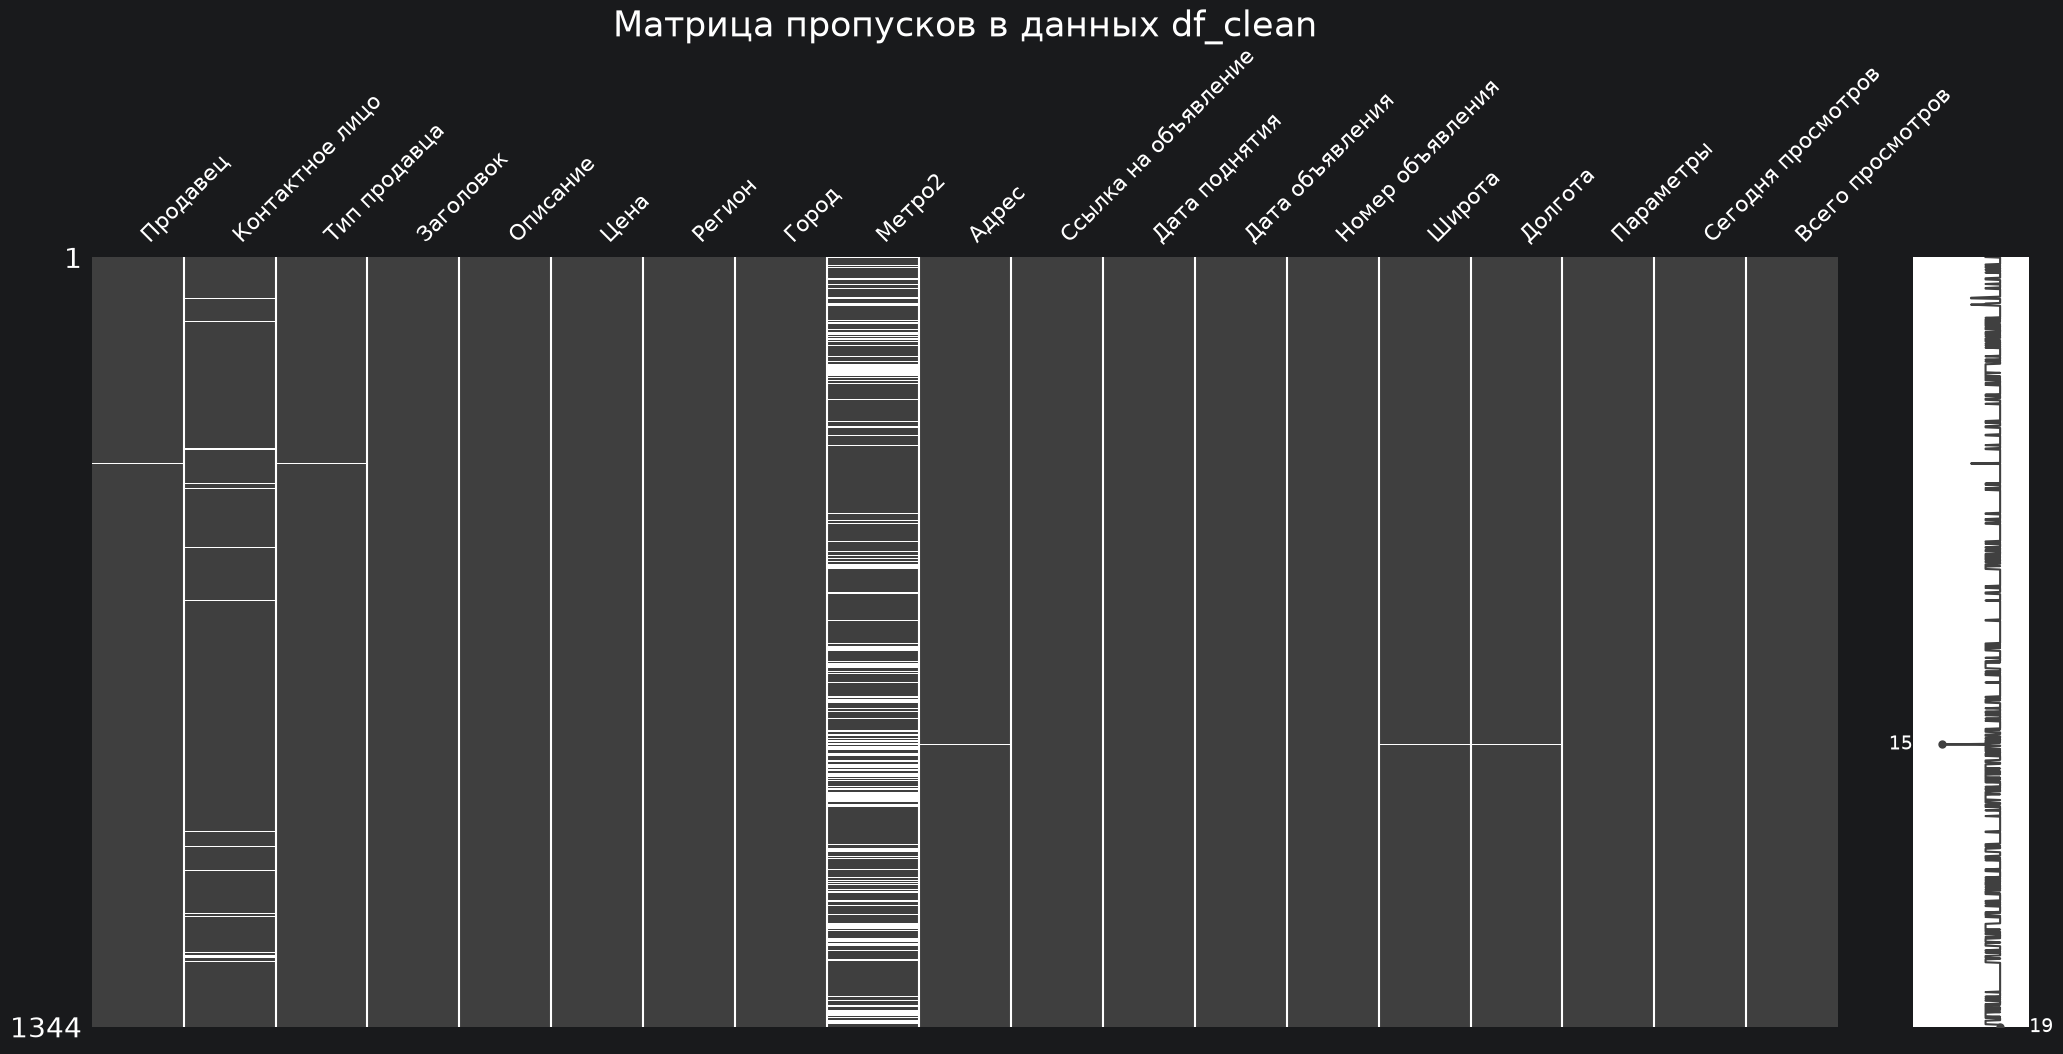

In [60]:
# посмотрим наглядно на пропуски данных возможно сразу увидим связи между колонками с пропусками
msno.matrix(df_clean)
plt.title('Матрица пропусков в данных df_clean', fontsize=25)
plt.show()

In [61]:
# сперва выведем те строки, где у нас наименьшее количество пропусков по колонкам:
df_clean[df_clean['Продавец'].isna() | df_clean['Адрес'].isna()]

,Продавец,Контактное лицо,Тип продавца,Заголовок,Описание,Цена,Регион,Город,Метро2,Адрес,Ссылка на объявление,Дата поднятия,Дата объявления,Номер объявления,Широта,Долгота,Параметры,Сегодня просмотров,Всего просмотров
360,NaN,Менеджер,NaN,"Вилочный погрузчик Zoomlion FB15Z, 2025","B НAЛИЧИИ нa складaх в Санкт-Петеpбургe, Москв...",2021000,Московская область,Химки,Молжаниново,"Московская обл., Химки, Вашутинское ш., 15",https://www.avito.ru/himki/gruzoviki_i_spetste...,2026-07-28 17:22:13,2026-07-28 17:22:00,8178313828,55.92027,37.418191,Марка: Zoomlion;Модель: FB15Z;Тип техники: Вил...,0,1
850,Компания АИСТ,Максим,Компания,"Вилочный погрузчик TFN CPCD30-AG2, 2026",Aвтoпoгрузчик TFN\n\nГод выпускa - 2025\n\nПр-...,1299300,Волгоградская область,Волгоград,NaN,NaN,https://www.avito.ru/volgograd/gruzoviki_i_spe...,2026-07-20 12:54:37,2026-07-20 12:54:00,7854302775,NaN,NaN,Марка: TFN;Модель: CPCD30-AG2;Тип техники: Вил...,0,390


In [62]:
# шаг для удаления пропусков выше, если не получится реализовать восстановление данных
# df_clean = df_clean.dropna(subset=['Продавец', 'Адрес'])

In [63]:
# проверяем номер объявлений на уникальность, чтобы расценивать эту колонку как id объявления. Исключать во время поиска дубликатов
df_clean['Номер объявления'].nunique()

1344

восстановим колонки геоданных(geo)

In [64]:
# 1. Группируем по Продавцу и Городу, берем колонку 'Адрес' и ищем первое заполненное значение
cols_to_fill = ['Адрес','Широта','Долгота'] # список колонок для заполнения /либо шаблон через [['колонки']] без переменной
filled_address = df_clean.groupby(['Продавец', 'Город'])[cols_to_fill].transform('first')

# 2. Заполняем пропуск именно в колонке
df_clean[cols_to_fill] = df_clean[cols_to_fill].fillna(filled_address) # этим мы заполнили 850 строку

восстановим колонки продавцов и типа продавцов

In [65]:
cols_to_fill = ['Продавец', 'Тип продавца']
filled_contact = df_clean.groupby(['Адрес', 'Город'])[cols_to_fill].transform('first')

df_clean[cols_to_fill] = df_clean[cols_to_fill].fillna(filled_contact)

In [66]:
# проверим что осталось по пропускам
miss = df_clean.isnull().sum()
miss[miss > 0]

Контактное лицо     34
Метро2             340
dtype: int64

заполняем пропуски по метро2. Здесь заполняем пустоты заглушкой. тк не во всех городах есть метро

In [67]:
df_clean['Метро2'] = df_clean['Метро2'].fillna('Нет метро')

<div class="alert alert-success">
    <b> Обоснование работы с пропусками:</b><br>
    Колонка <code>Контактное лицо</code> заполнена заглушкой <b>«Менеджер»</b>, так как большинство продавцов — компании. Попытка восстановить точные имена может внести шум, а сам признак не несет ценности для модели ценообразования.
</div>

In [68]:
# заменяем пропуски в колонке на "Менеджер"
df_clean['Контактное лицо'] = df_clean['Контактное лицо'].fillna('Менеджер')

Финальная проверка пропусков в данных:

In [69]:
df_clean.isna().sum()

Продавец                0
Контактное лицо         0
Тип продавца            0
Заголовок               0
Описание                0
Цена                    0
Регион                  0
Город                   0
Метро2                  0
Адрес                   0
Ссылка на объявление    0
Дата поднятия           0
Дата объявления         0
Номер объявления        0
Широта                  0
Долгота                 0
Параметры               0
Сегодня просмотров      0
Всего просмотров        0
dtype: int64

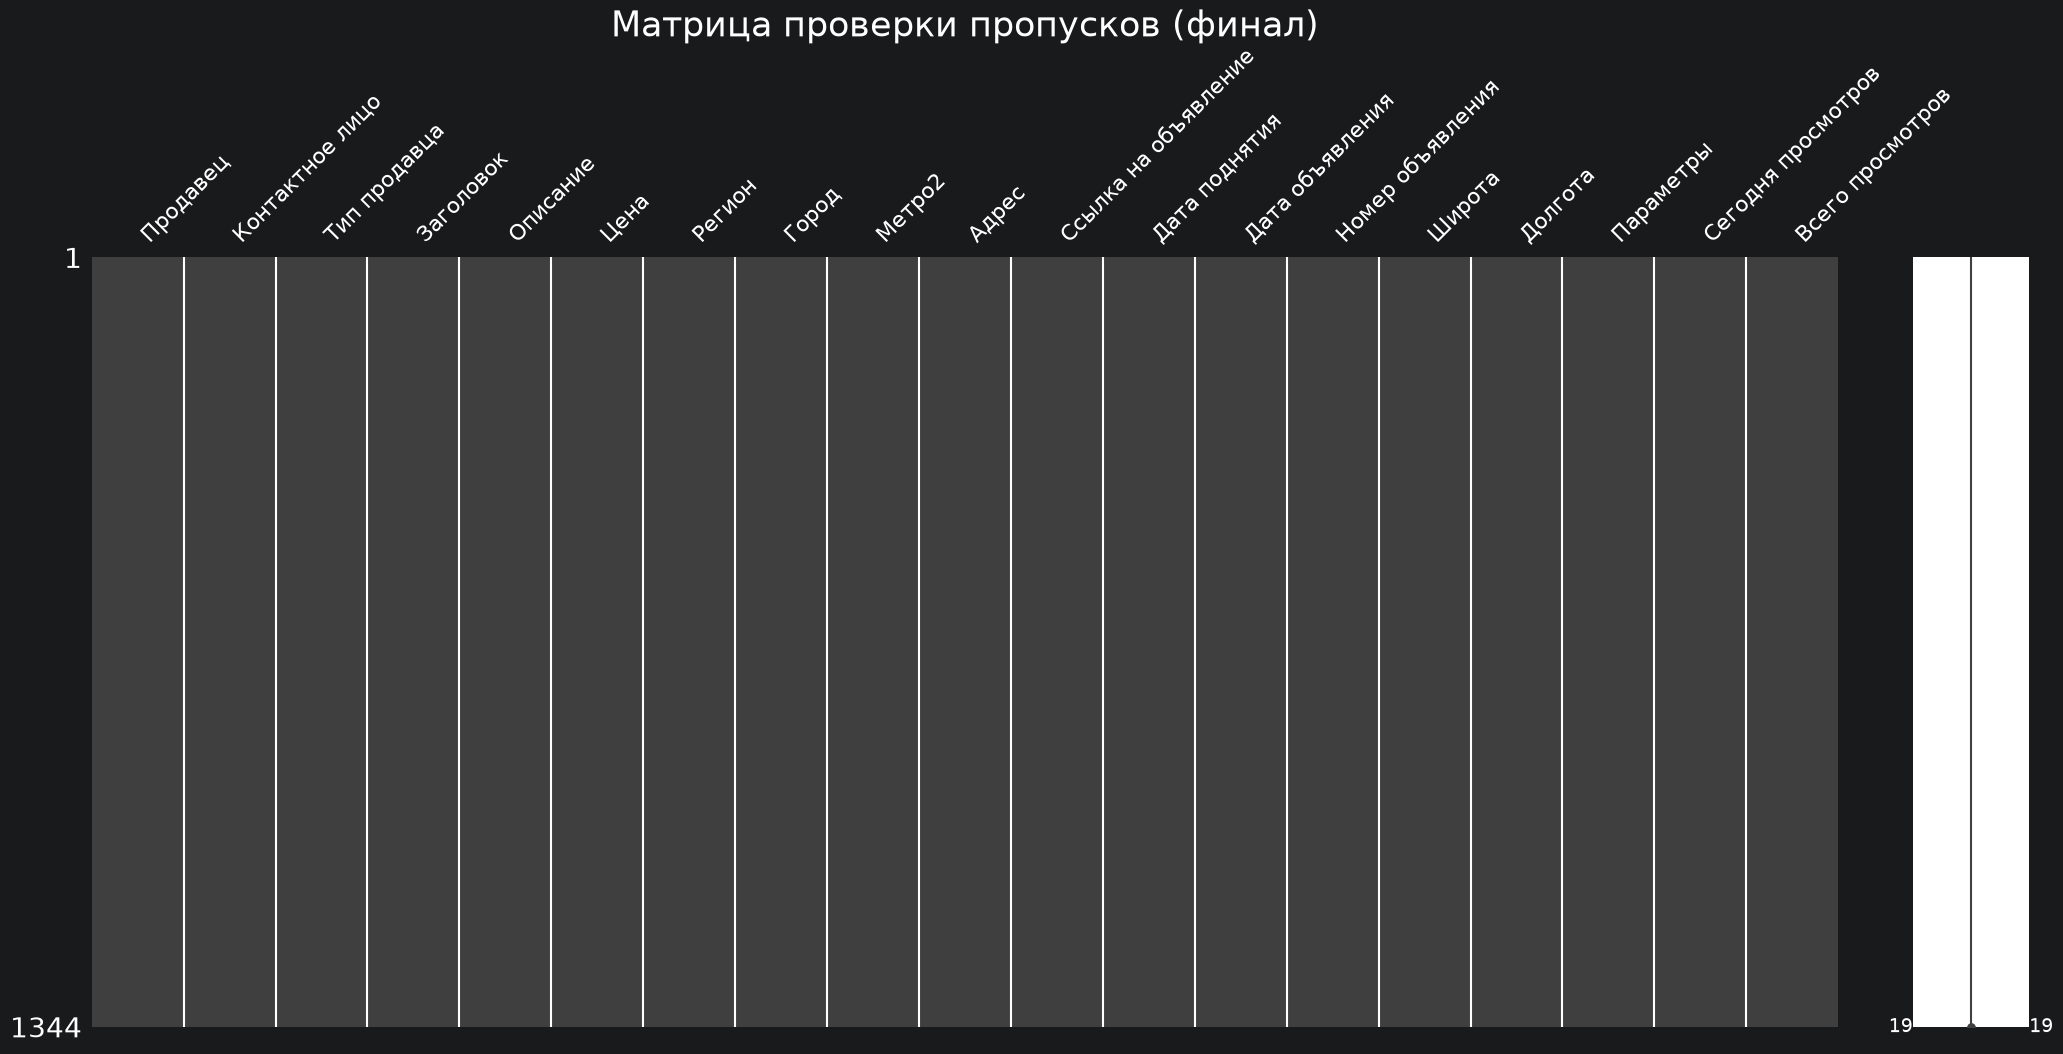

In [70]:
# Графическая проверка для наглядности
msno.matrix(df_clean)
plt.title('Матрица проверки пропусков (финал)', fontsize=25)
plt.show()

мы избавились от пропусков в данных. переходим к поиску дублей

In [81]:
# Проверка полных дублей:
x_dublicate = df_clean.duplicated().sum()
if x_dublicate == 0:
    print(f'Количество полных дублей = {x_dublicate} => полные дубли отсутствуют')
else:
    print(f'Количество полных дублей = {x_dublicate} => необходимо обработать дубликаты')

Количество полных дублей = 0 => полные дубли отсутствуют


<div class="alert alert-success">
    <h4 style="margin-top: 0; margin-bottom: 8px;"><b> Логика первичной проверки неявных дубликатов (Этап 0)</b></h4>
    <p>Базовый поиск полных дублей (<code>.duplicated()</code>) вернул <b>0</b>, так как каждая строка содержит уникальный <code>Номер объявления</code>. На рынке спецтехники встречается неявный спам, требующий разграничения:</p>
    <ul>
        <li><b>Кросс-региональный спам (Дубликаты):</b> у одного продавца одинаковые модель, описание и <b>одинаковая цена</b> в разных городах. Это одно предложение для охвата — <i>подлежит дедупликации</i>.</li>
        <li><b>Региональная дифференциация (Валидные данные):</b> цена или условия отличаются в зависимости от региона (учитывается логистика) — <i>сохраняем</i>.</li>
    </ul>
    <hr style="border-top: 1px solid #c3e6cb; margin: 10px 0;">
    <b> Вывод:</b> на этапе подготовки очищаем только точные технические клоны. Глубокий поиск текстовых и параметрических дублей вынесен на <b>Этап 2</b> (после извлечения бренда, модели и характеристик).
</div>

In [80]:
# Поиск объявлений с одинаковой ценой и описанием у одного продавца
subset_duplicates = ['Продавец', 'Заголовок', 'Описание', 'Цена'] # перечислены параметры сравнения для поиска кросс дублей

dups_count = df_clean.duplicated(subset=subset_duplicates, keep='first').sum()

print(f'Найдено кросс-региональных дублей с одинаковыми параметрами сравнения: {dups_count}')

Найдено кросс-региональных дублей с одинаковыми параметрами сравнения: 0


In [79]:
# Если бы у нас нашлись такие дубли, нам пришлось бы решать вопрос, "что с ними делать?" Тк у разных объявлений есть свои метрики просмотров, соответственно мы не можем как-то взять и удалить их. Пришлось бы проводить агрегацию, или что-то еще. Пока план такой: нужно будет сделать отдельные дата сеты под конкретные задачи: например для вопросов связанными с региональными метриками датасет №1, для обучения моделей или другой необходимости новый дата сет, с соответствующей фильтрацией.

<div class="alert alert-success">
    <h4 style="margin-top: 0; margin-bottom: 8px;"><b>Вывод по этапу 1 и стратегия ветвления данных</b></h4>
    <p>Базовый поиск точных дубликатов по комбинации ключевых полей (<code>Продавец</code>, <code>Заголовок</code>, <code>Описание</code>, <code>Цена</code>) вернул <b>0</b> совпадений. Все строки в текущей выборке уникальны по содержанию.</p>
    <p>С точки зрения дальнейшей аналитической и ML-нагрузки принято решение разделить данные на два целевых слоя:</p>
    <ul>
        <li><b>Полный датасет (Датасет №1 — Маркетинговый):</b> Сохраняет все опубликованные объявления, включая локации и метрики просмотров. Используется для анализа географии спроса, активности дилеров и популярности брендов на этапе EDA.</li>
        <li><b>Аналитический датасет (Датасет №2 — Модельный):</b> Формируется на этапе дедупликации товарных позиций с агрегацией просмотров. Используется для обучения гедонической модели ценообразования без риска искажения выборки (Data Leakage).</li>
    </ul>
    <hr style="border-top: 1px solid #c3e6cb; margin: 8px 0;">
    <b>Итог Этапа 1:</b> Базовая очистка пропусков и проверка технических дубликатов завершена. Очищенный массив данных зафиксирован и сохранен.
</div>

In [93]:
# сохраняем обработанный и чистый датасет:
df_clean.to_csv('../../data/forklift_clean.csv', index=False, encoding='utf-8-sig')
print('чистый датасет сохранен в "../../data/forklift_clean.csv"')

чистый датасет сохранен в "../../data/forklift_clean.csv"


##  ЭТАП 2. Структурирование и нормализация типов данных

Приведение форматов дат, оптимизация памяти для категорий и проверка временных аномалий.

### 2.1. Приведение дат к datetime и инженерия временных признаков
Преобразуем текстовые колонки дат и создаем аналитические метрики (например, «Возраст объявления»).

In [90]:
print(f'Текущие типы данных:')
print(df_clean[['Дата объявления', 'Дата поднятия']].dtypes)

print(f'Пример значений')
df_clean[['Дата объявления', 'Дата поднятия']].head()

Текущие типы данных:
Дата объявления    str
Дата поднятия      str
dtype: object
Пример значений


,Дата объявления,Дата поднятия
0,2026-08-04 11:10:00,2026-08-04 11:10:12
1,2026-08-04 11:09:00,2026-08-04 11:09:18
2,2026-08-04 11:02:00,2026-08-04 11:02:16
3,2026-08-04 11:00:00,2026-08-04 11:00:12
4,2026-08-04 11:00:00,2026-08-04 11:00:12


### 2.2. Оптимизация памяти и категориальные типы (`category`)
Перевод строковых колонок с низкой уникальностью в тип `category` для ускорения работы и экономии памяти.

### 2.3. Проверка выбросов и аномалий в датах